$$\Large \textit{Colegio Químico del Perú | Región Cusco}$$
$$\large \textbf{Sesión 6 - Cuaderno 2 | Perfil de Energía}$$

_Dr. Jesus Alvarado Huayhuaz_

# 1. Introducción

1. Relaxed Surface Scan

En español, **Escaneo relajado de la superficie de energía potencial** (también se dice barrido relajado de la superficie de energía potencial).

*Idea básica:*

Se explora la superficie de energía potencial (PES) variando gradualmente una coordenada geométrica (por ejemplo, una distancia de enlace, ángulo o dihedro) mientras el resto de la estructura se optimiza.

*Procedimiento:*

Se fija una coordenada estructural (por ejemplo, la distancia entre dos átomos).

Esa coordenada se cambia paso a paso.

En cada paso se optimizan todas las demás coordenadas.

Se obtiene un perfil de energía.

*Resultado:*

El punto de máxima energía en el perfil suele estar cerca del estado de transición.

*Uso típico:*

Reacciones simples donde se sabe qué enlace se rompe o se forma.

2. Nudged Elastic Band (NEB)

En español, **Método de la banda elástica nudged** (o más formalmente método de la banda elástica corregida).

*Idea básica:*

Este método encuentra el camino de mínima energía (MEP, Minimum Energy Path) entre reactivos y productos.

*Procedimiento:*

Se define la estructura inicial (reactivos) y la final (productos).

Se generan varias estructuras intermedias llamadas imágenes.

Estas imágenes se conectan mediante resortes ficticios (elastic band).

*Durante la optimización:*

las imágenes se ajustan para seguir el camino de menor energía,

los resortes mantienen una separación uniforme entre ellas.

*Resultado:*

La imagen con mayor energía corresponde aproximadamente al estado de transición.

*Uso típico:*

- Reacciones complejas

- Procesos en superficies catalíticas o sólidos

- Cuando no se conoce la coordenada de reacción

| Método               | Traducción                                             | Idea principal                                                    |
| -------------------- | ------------------------------------------------------ | ----------------------------------------------------------------- |
| Relaxed Surface Scan | Escaneo relajado de la superficie de energía potencial | Se modifica una coordenada y se optimiza el resto                 |
| NEB                  | Método de la banda elástica nudged                     | Encuentra el camino de mínima energía entre reactivos y productos |


# 2. Requerimientos

In [ ]:
!pip install condacolab

In [ ]:
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:15
🔁 Restarting kernel...


In [ ]:
!conda install conda-forge::xtb

Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - conda-forge::xtb


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    dftd4-3.7.0                |       hd37a5e2_4         577 KB  conda-forge
    jonquil-0.3.0              |       hb1d0f04_2         106 KB  conda-forge
    libblas-3.11.0             |5_h4a7cf45_openblas          18 KB  conda-forge
    libgcc-15.2.0              |      he0feb66_18        1017 KB  conda-forge
    libgcc-ng-15.2.0           |      h69a702a_18          27 KB  conda-forge
    libgfortran-15.2.0         |      h69

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Ejemplo: Aspirina vs serina

**Reactantes**

aspirina sin H (anión):

CC(=O)OC1=CC=CC=C1C(=O)[O-]

serinaH:

OCC(N)C(=O)O

**Productos**

aspirinaH:

CC(=O)OC1=CC=CC=C1C(=O)O

serina sin H (anión):

[O-]CC(N)C(=O)O

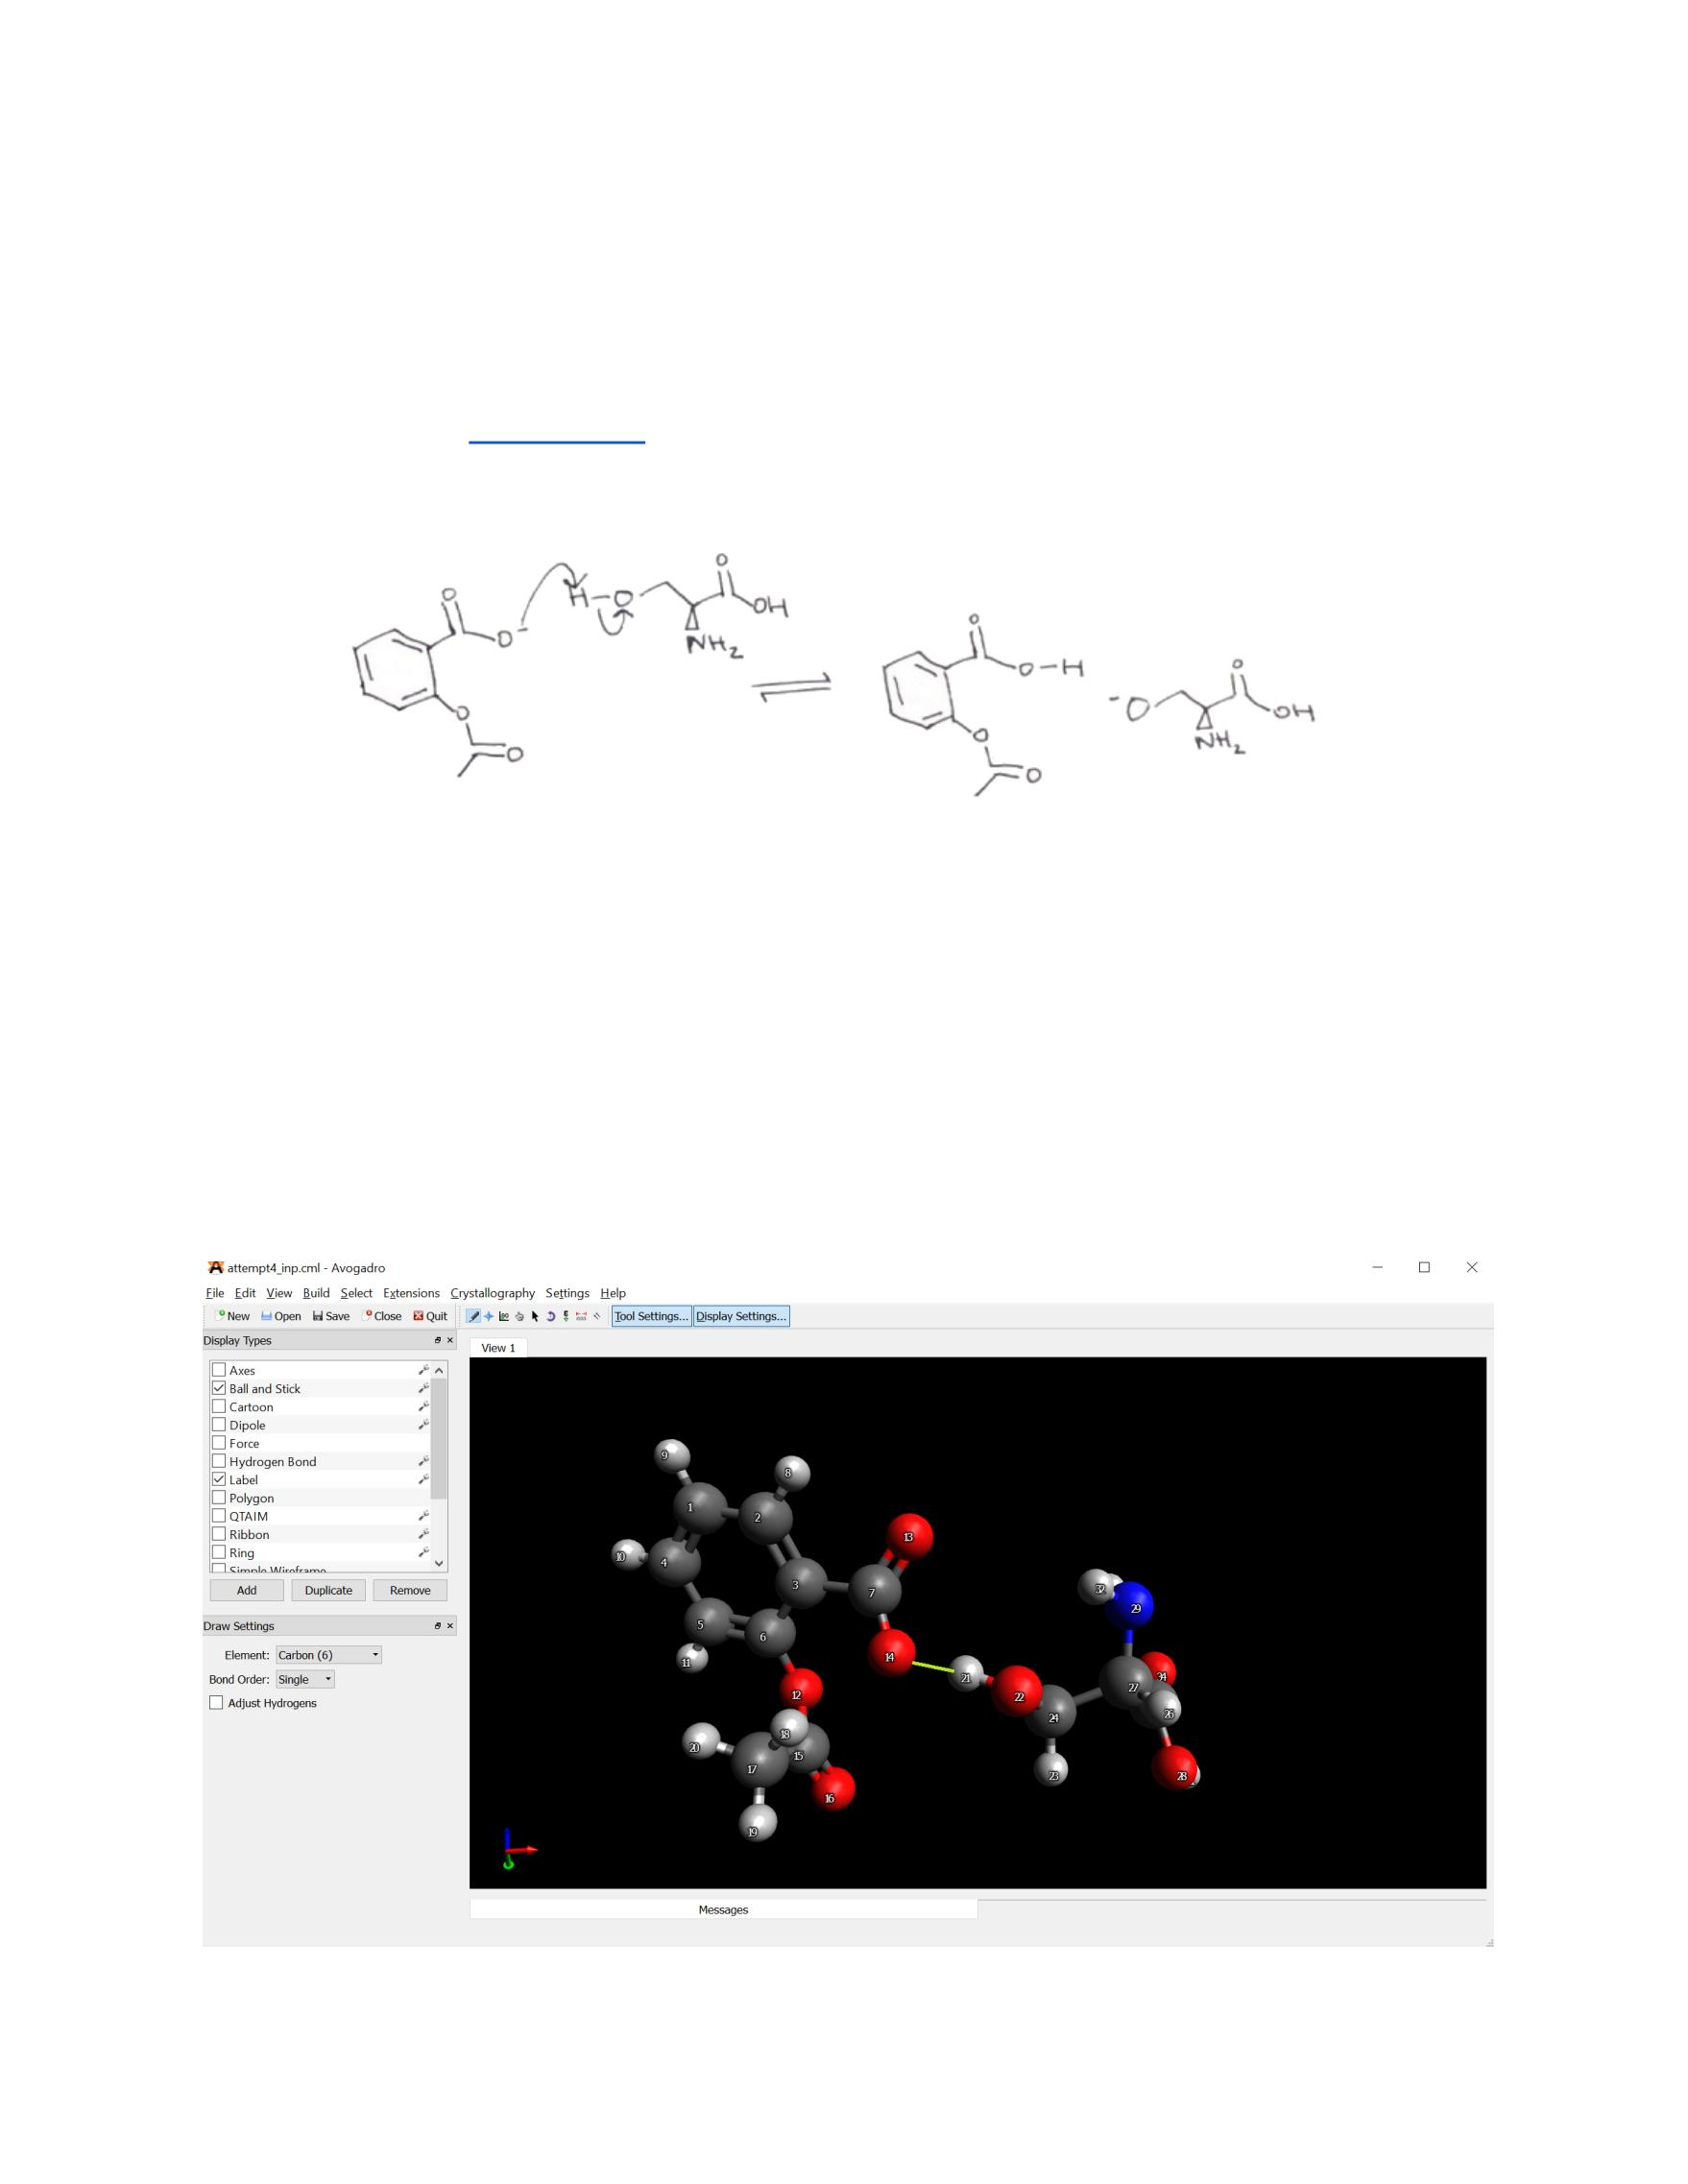

Avogadro (imagen arriba) y GaussView (imagen siguiente) son excelentes herramientas para la generación de inputs para estudiar los mecanismos de reacción

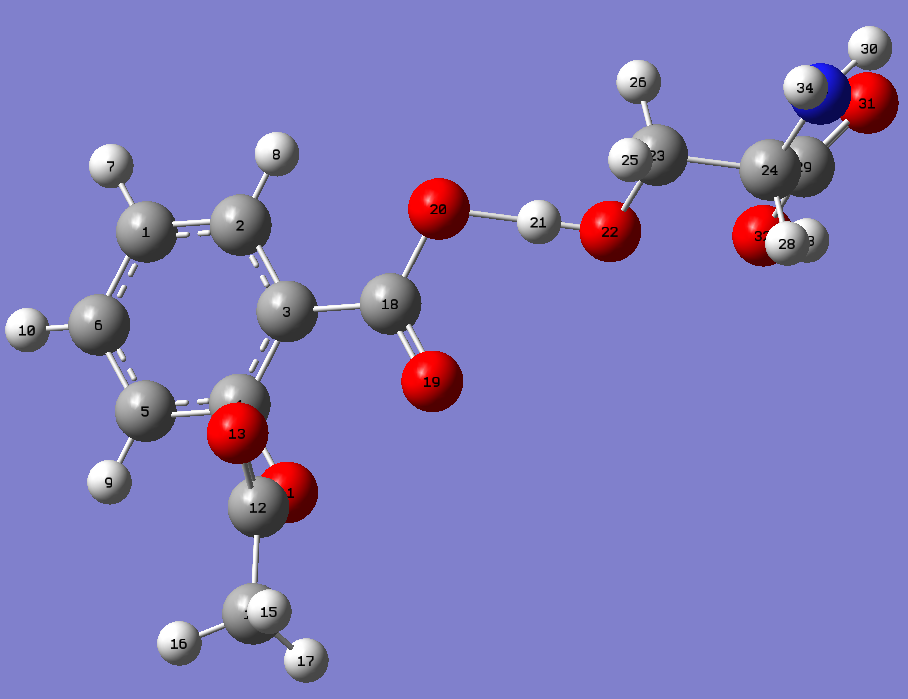

## 3.1 Script de partida

In [ ]:
!wget https://raw.githubusercontent.com/inefable12/mecanismos/refs/heads/main/moleculas/complejo.xyz

--2026-03-16 23:49:08--  https://raw.githubusercontent.com/inefable12/mecanismos/refs/heads/main/moleculas/complejo.xyz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2025 (2.0K) [text/plain]
Saving to: ‘complejo.xyz’

complejo.xyz        100%[===================>]   1.98K  --.-KB/s    in 0s      

2026-03-16 23:49:08 (31.4 MB/s) - ‘complejo.xyz’ saved [2025/2025]



In [ ]:
import math

archivo = "complejo.xyz"

# índices (numeración química)
O_acceptor = 20
H = 21
O_donor = 22

atoms = []
coords = []

# ======================
# Leer archivo xyz
# ======================

with open(archivo) as f:
    lines = f.readlines()

n_atoms = int(lines[0])

for line in lines[2:2+n_atoms]:
    p = line.split()
    atoms.append(p[0])
    coords.append([float(p[1]), float(p[2]), float(p[3])])

# ======================
# coordenadas clave
# ======================

Oa = coords[O_acceptor-1]
Hd = coords[H-1]
Od = coords[O_donor-1]

# ======================
# vector O_acceptor -> O_donor
# ======================

vx = Od[0] - Oa[0]
vy = Od[1] - Oa[1]
vz = Od[2] - Oa[2]

norm = math.sqrt(vx*vx + vy*vy + vz*vz)

vx /= norm
vy /= norm
vz /= norm

# ======================
# nueva posición del H
# ======================

OH_dist = 0.98

newH = [
    Oa[0] + vx * OH_dist,
    Oa[1] + vy * OH_dist,
    Oa[2] + vz * OH_dist
]

coords[H-1] = newH

# ======================
# escribir producto.xyz
# ======================

with open("producto.xyz","w") as f:

    f.write(f"{n_atoms}\n")
    f.write("producto aproximado proton transfer\n")

    for atom,(x,y,z) in zip(atoms,coords):
        f.write(f"{atom} {x:.6f} {y:.6f} {z:.6f}\n")

print("producto.xyz generado correctamente")

producto.xyz generado correctamente


## 3.2 Comando de ejecución

In [ ]:
!xtb complejo.xyz --path producto.xyz --gfn2 --chrg -1 --uhf 0

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.7.1 (edcfbbe) compiled by 'conda@c0858423619e' on 2025-09-04

   xtb is free software: you can redistribute it and/or modify it under
   the terms of the GNU Lesser General Public License as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
   
   xtb is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; w

demoró 4 min

## 3.3 Leer energías desde xtbpath.xyz

In [ ]:
energies = []

with open("xtbpath.xyz") as f:
    lines = f.readlines()

for line in lines:
    if "energy" in line.lower():
        parts = line.split()
        e = float(parts[1])
        energies.append(e)

energies = np.array(energies)

# convertir a kcal/mol relativas
energies = (energies - energies.min()) * 627.509
energies

array([31911.61427042,  1989.74765788,   753.1789455 ,   116.03215466,
           0.        ,   131.27402489,   578.63582602,  1283.28797274,
        2275.51808177,  3496.5273975 ,  4874.27923013,  6148.571955  ,
        7267.53160044,  8286.05745034,  9225.3981327 , 10175.77274365,
       11154.87503816, 12143.4283887 , 13125.4019022 , 14104.96760101,
       14972.95630672, 15713.11299989, 16324.93646207, 16729.46744762,
       17123.38406018, 17508.12485447, 17867.62207306, 18209.85925488,
       18570.01367207, 18952.68374153, 19225.89150182, 19472.05385034,
       19973.6925791 , 20724.1905949 , 21673.91482722, 22664.9210948 ,
       24281.25722631, 26140.18592708, 28070.40793674, 29218.88813585,
       29334.68110166, 28867.41781265, 28302.81130869, 27710.66203627,
       27263.24829189, 26915.79773973, 26791.39368425, 27872.68746244])

In [ ]:
energies = np.delete(energies, 0)
energies

array([    0.        ,   131.27402489,   578.63582602,  1283.28797274,
        2275.51808177,  3496.5273975 ,  4874.27923013,  6148.571955  ,
        7267.53160044,  8286.05745034,  9225.3981327 , 10175.77274365,
       11154.87503816, 12143.4283887 , 13125.4019022 , 14104.96760101,
       14972.95630672, 15713.11299989, 16324.93646207, 16729.46744762,
       17123.38406018, 17508.12485447, 17867.62207306, 18209.85925488,
       18570.01367207, 18952.68374153, 19225.89150182, 19472.05385034,
       19973.6925791 , 20724.1905949 , 21673.91482722, 22664.9210948 ,
       24281.25722631, 26140.18592708, 28070.40793674, 29218.88813585,
       29334.68110166, 28867.41781265, 28302.81130869, 27710.66203627,
       27263.24829189, 26915.79773973, 26791.39368425, 27872.68746244])

## 3.4 Encontrar TS

In [ ]:
ts_index = np.argmax(energies)

print("Número de imágenes:", len(energies))
print("TS aproximado en imagen:", ts_index)
print("Energía de barrera (kcal/mol):", energies[ts_index])

Número de imágenes: 44
TS aproximado en imagen: 36
Energía de barrera (kcal/mol): 29334.681101661517


## 3.5 Graficar perfil de energía

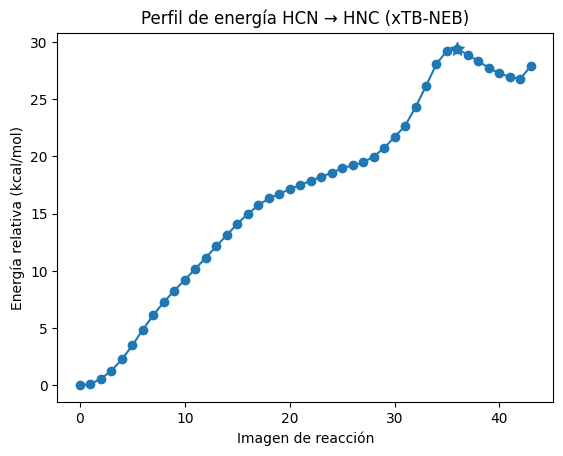

In [ ]:
plt.figure()

plt.plot(range(len(energies)), energies/1000, marker="o")

plt.xlabel("Imagen de reacción")
plt.ylabel("Energía relativa (kcal/mol)")
plt.title("Perfil de energía HCN → HNC (xTB-NEB)")

plt.scatter(ts_index, energies[ts_index]/1000, s=100, marker="*")

plt.show()